# 🎓 Student Performance Prediction System
## Using Machine Learning (Linear Regression)

---

This notebook demonstrates a complete machine learning workflow for predicting student academic performance based on study behavior and academic history.

**Dataset:** 5000 Student Records  
**Algorithm:** Linear Regression  
**Features:** StudyHours, Attendance, SleepHours, PreviousScore  
**Target:** FinalScore

## Step 1: Import Required Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../dataset/student_performance_dataset.csv')

print(f'✅ Dataset loaded successfully!')
print(f'📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n📋 Column Names: {list(df.columns)}')

✅ Dataset loaded successfully!
📊 Dataset Shape: 5000 rows × 5 columns

📋 Column Names: ['StudyHours', 'Attendance', 'SleepHours', 'PreviousScore', 'FinalScore']


In [3]:
# Display first 10 records
print('🔍 First 10 Records:')
df.head(10)

🔍 First 10 Records:


,StudyHours,Attendance,SleepHours,PreviousScore,FinalScore
0,5.1,63.6,5.6,65.0,76.6
1,11.5,68.4,5.3,82.3,100.0
2,9.1,91.3,4.2,69.4,100.0
3,7.6,60.4,7.3,35.8,77.7
4,2.7,92.2,6.3,43.0,72.9
5,2.7,45.3,9.1,45.4,58.5
6,1.6,86.6,3.2,48.1,55.1
7,10.5,90.9,7.5,69.6,100.0
8,7.6,50.9,8.3,65.3,90.5
9,8.8,65.8,8.3,44.2,93.6


In [4]:
# Display last 10 records
print('🔍 Last 10 Records:')
df.tail(10)

🔍 Last 10 Records:


,StudyHours,Attendance,SleepHours,PreviousScore,FinalScore
4990,11.7,67.0,9.6,70.2,100.0
4991,7.3,59.5,7.1,83.2,99.2
4992,4.8,68.3,4.7,36.3,68.1
4993,8.1,89.1,5.8,64.5,100.0
4994,1.8,47.5,8.3,93.1,72.7
4995,10.9,91.5,7.6,91.4,100.0
4996,2.3,93.9,4.2,33.3,57.0
4997,4.6,96.8,3.4,51.3,76.0
4998,10.0,63.8,7.8,61.0,100.0
4999,7.6,53.0,4.8,42.1,84.0


In [5]:
# Display data types
print('📝 Data Types:')
print(df.dtypes)
print(f'\n📊 Dataset Info:')
df.info()

📝 Data Types:
StudyHours       float64
Attendance       float64
SleepHours       float64
PreviousScore    float64
FinalScore       float64
dtype: object

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StudyHours     5000 non-null   float64
 1   Attendance     5000 non-null   float64
 2   SleepHours     5000 non-null   float64
 3   PreviousScore  5000 non-null   float64
 4   FinalScore     5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


## Step 3: Data Cleaning & Preprocessing

In [6]:
# Check for missing values
print('🔍 Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

🔍 Missing Values:
StudyHours       0
Attendance       0
SleepHours       0
PreviousScore    0
FinalScore       0
dtype: int64

Total missing values: 0


In [7]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f'🔍 Duplicate Records: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'✅ Removed {duplicates} duplicate records')
    print(f'📊 Updated Dataset Shape: {df.shape}')
else:
    print('✅ No duplicate records found!')

🔍 Duplicate Records: 0
✅ No duplicate records found!


In [8]:
# Dataset Statistics
print('📊 Dataset Statistics:')
df.describe()

📊 Dataset Statistics:


,StudyHours,Attendance,SleepHours,PreviousScore,FinalScore
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.465220,69.488820,6.509400,65.537560,85.660340
std,3.186605,17.136524,2.035654,20.146699,14.672759
min,1.000000,40.000000,3.000000,30.000000,38.200000
25%,3.700000,54.800000,4.700000,48.400000,74.900000
50%,6.500000,69.200000,6.500000,65.900000,89.200000
75%,9.200000,84.000000,8.300000,82.600000,100.000000
max,12.000000,100.000000,10.000000,100.000000,100.000000


## Step 4: Data Visualization

### 4.1 Scatter Plot - Study Hours vs Final Score

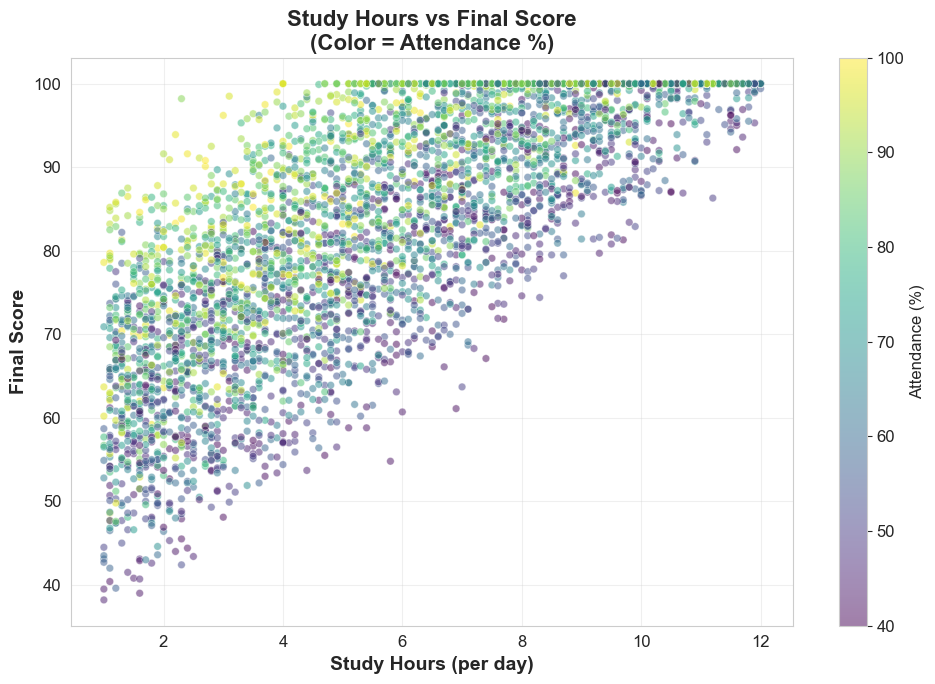

✅ Scatter plot generated!


In [9]:
# Scatter Plot: Study Hours vs Final Score
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['StudyHours'], df['FinalScore'],
                      c=df['Attendance'], cmap='viridis',
                      alpha=0.5, edgecolors='white', linewidths=0.5, s=30)
plt.xlabel('Study Hours (per day)', fontsize=14, fontweight='bold')
plt.ylabel('Final Score', fontsize=14, fontweight='bold')
plt.title('Study Hours vs Final Score\n(Color = Attendance %)', fontsize=16, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Attendance (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../screenshots/scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter plot generated!')

### 4.2 Correlation Heatmap

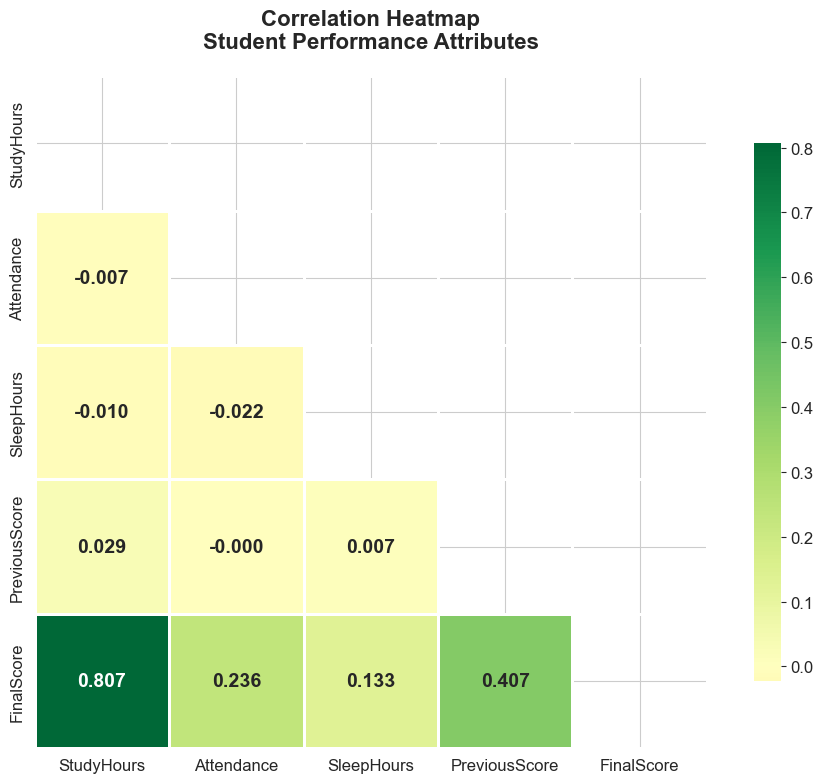

✅ Heatmap generated!

📊 Correlation with FinalScore:
FinalScore       1.000000
StudyHours       0.806545
PreviousScore    0.406731
Attendance       0.235956
SleepHours       0.132806
Name: FinalScore, dtype: float64


In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='RdYlGn',
            mask=mask, center=0, square=True,
            linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Correlation Heatmap\nStudent Performance Attributes', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../screenshots/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap generated!')
print(f'\n📊 Correlation with FinalScore:')
print(correlation['FinalScore'].sort_values(ascending=False))

### 4.3 Distribution Histograms

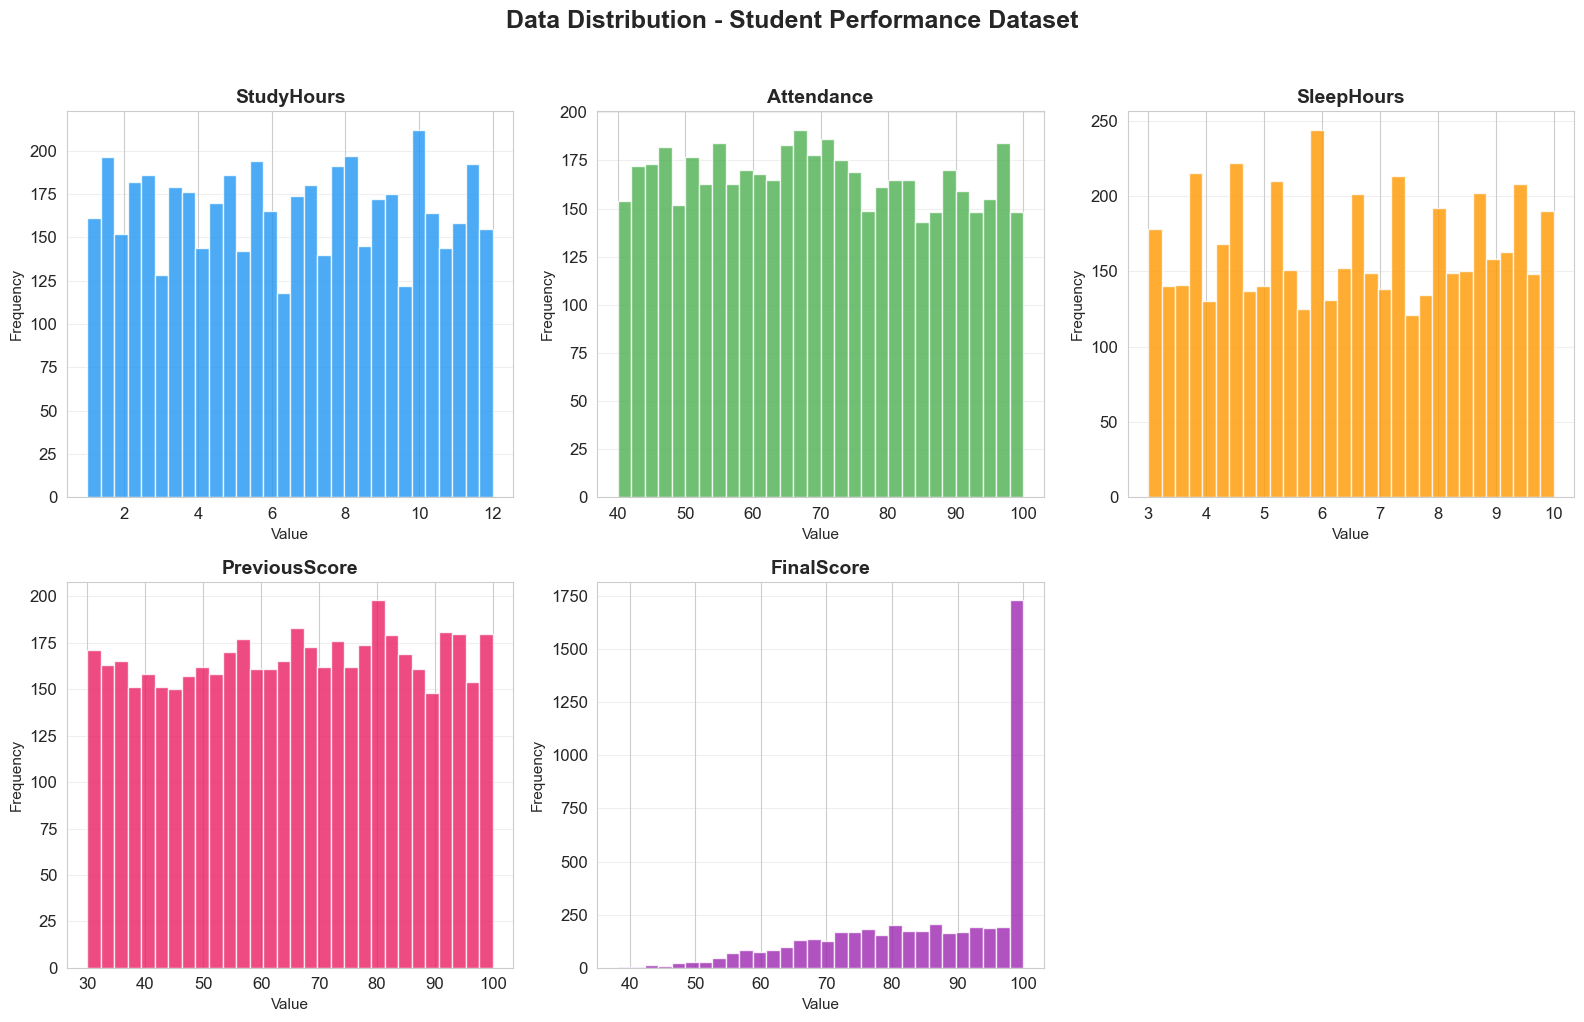

✅ Histograms generated!


In [11]:
# Distribution Histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Data Distribution - Student Performance Dataset', fontsize=18, fontweight='bold', y=1.02)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for idx, (col, color) in enumerate(zip(df.columns, colors)):
    row, col_idx = divmod(idx, 3)
    axes[row][col_idx].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.8)
    axes[row][col_idx].set_title(col, fontsize=14, fontweight='bold')
    axes[row][col_idx].set_xlabel('Value', fontsize=11)
    axes[row][col_idx].set_ylabel('Frequency', fontsize=11)
    axes[row][col_idx].grid(axis='y', alpha=0.3)

axes[1][2].axis('off')
plt.tight_layout()
plt.savefig('../screenshots/histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Histograms generated!')

### 4.4 Pair Plot

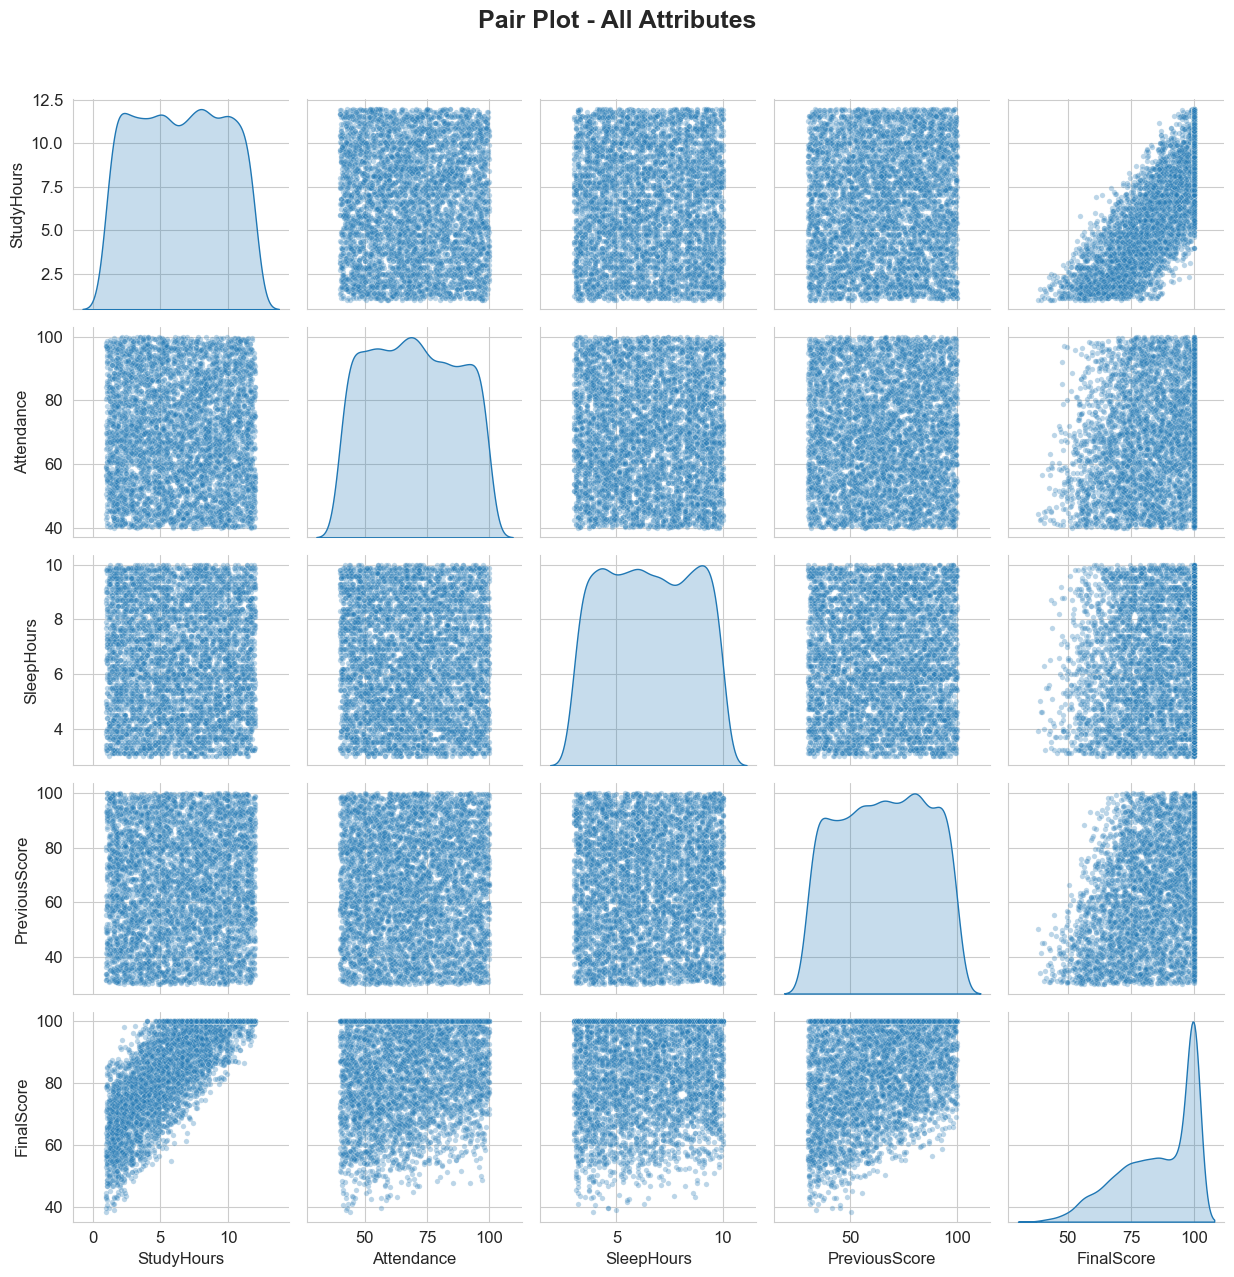

✅ Pair plot generated!


In [12]:
# Pair Plot
pair_plot = sns.pairplot(df, diag_kind='kde',
                         plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'white', 'linewidth': 0.3},
                         diag_kws={'fill': True})
pair_plot.fig.suptitle('Pair Plot - All Attributes', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Pair plot generated!')

## Step 5: Feature Selection & Train-Test Split

In [13]:
# Define features (X) and target (y)
X = df[['StudyHours', 'Attendance', 'SleepHours', 'PreviousScore']]
y = df['FinalScore']

print(f'📌 Features (X): {list(X.columns)}')
print(f'📌 Target (y): FinalScore')
print(f'📌 Total samples: {len(df)}')

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'\n📊 Training Data: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'📊 Testing Data:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)')

📌 Features (X): ['StudyHours', 'Attendance', 'SleepHours', 'PreviousScore']
📌 Target (y): FinalScore
📌 Total samples: 5000

📊 Training Data: 4000 samples (80%)
📊 Testing Data:  1000 samples (20%)


## Step 6: Model Training (Linear Regression)

In [14]:
# Initialize and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Linear Regression model trained successfully!')
print(f'\n📐 Model Coefficients:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'   {feature}: {coef:.4f}')
print(f'   Intercept: {model.intercept_:.4f}')

✅ Linear Regression model trained successfully!

📐 Model Coefficients:
   StudyHours: 3.6894
   Attendance: 0.2126
   SleepHours: 1.0174
   PreviousScore: 0.2818
   Intercept: 21.9592


## Step 7: Prediction

In [15]:
# Predict on test data
y_pred = model.predict(X_test)

# Display predictions comparison
comparison = pd.DataFrame({
    'Actual Score': y_test.values[:20],
    'Predicted Score': np.round(y_pred[:20], 2),
    'Difference': np.round(np.abs(y_test.values[:20] - y_pred[:20]), 2)
})
print('📋 Prediction Results (First 20 Samples):')
comparison

📋 Prediction Results (First 20 Samples):


,Actual Score,Predicted Score,Difference
0,92.5,86.63,5.87
1,65.7,68.33,2.63
2,79.6,77.97,1.63
3,89.9,83.80,6.10
4,100.0,101.96,1.96
5,65.7,70.15,4.45
6,54.2,61.76,7.56
7,100.0,96.10,3.90
8,64.6,68.75,4.15
9,69.7,70.91,1.21


## Step 8: Performance Evaluation

In [16]:
# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('📊 Performance Metrics:')
print(f'   ├── Mean Absolute Error (MAE):  {mae:.4f}')
print(f'   ├── Mean Squared Error (MSE):   {mse:.4f}')
print(f'   ├── Root Mean Squared Error:    {rmse:.4f}')
print(f'   └── R² Score:                   {r2:.4f} ({r2*100:.2f}%)')

if r2 >= 0.9:
    print(f'\n🌟 Excellent model performance! R² = {r2:.4f}')
elif r2 >= 0.7:
    print(f'\n✅ Good model performance! R² = {r2:.4f}')
elif r2 >= 0.5:
    print(f'\n⚠️ Moderate model performance. R² = {r2:.4f}')
else:
    print(f'\n❌ Poor model performance. R² = {r2:.4f}')

📊 Performance Metrics:
   ├── Mean Absolute Error (MAE):  4.1614
   ├── Mean Squared Error (MSE):   27.8640
   ├── Root Mean Squared Error:    5.2786
   └── R² Score:                   0.8686 (86.86%)

✅ Good model performance! R² = 0.8686


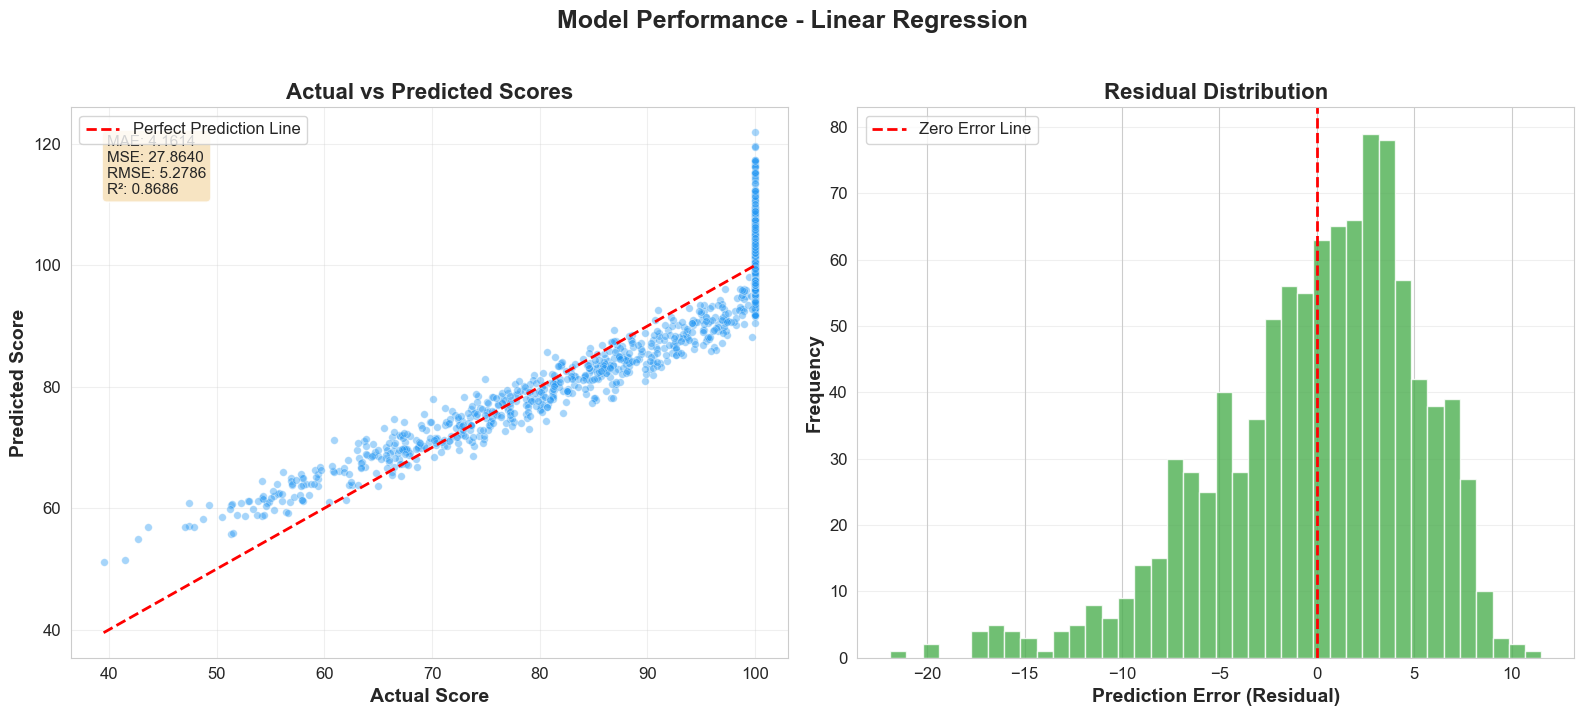

✅ Prediction result plot saved!


In [17]:
# Visualization: Actual vs Predicted & Residual Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#2196F3', edgecolors='white', linewidths=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction Line')
axes[0].set_xlabel('Actual Score', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Predicted Score', fontsize=14, fontweight='bold')
axes[0].set_title('Actual vs Predicted Scores', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Add metrics text box
metrics_text = f'MAE: {mae:.4f}\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Residual Distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
axes[1].set_xlabel('Prediction Error (Residual)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[1].set_title('Residual Distribution', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Model Performance - Linear Regression', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction result plot saved!')

## Step 9: Custom Prediction Demo

In [18]:
# Custom predictions for sample students
sample_students = pd.DataFrame({
    'StudyHours': [8.0, 3.0, 6.5, 10.0, 2.0],
    'Attendance': [90, 50, 75, 95, 40],
    'SleepHours': [7.0, 5.0, 6.5, 8.0, 4.0],
    'PreviousScore': [85, 45, 65, 92, 35]
})

predictions = model.predict(sample_students)
sample_students['PredictedScore'] = np.round(predictions, 2)

print('🎯 Custom Predictions for Sample Students:')
sample_students

🎯 Custom Predictions for Sample Students:


,StudyHours,Attendance,SleepHours,PreviousScore,PredictedScore
0,8.0,90,7.0,85,101.69
1,3.0,50,5.0,45,61.43
2,6.5,75,6.5,65,86.82
3,10.0,95,8.0,92,113.12
4,2.0,40,4.0,35,51.78


## Summary

The Student Performance Prediction System successfully demonstrates:

- ✅ Data loading and exploration
- ✅ Data cleaning and preprocessing
- ✅ Data visualization (Scatter Plot, Heatmap, Histograms, Pair Plot)
- ✅ Model training using Linear Regression
- ✅ Performance evaluation using MAE, MSE, and R² Score
- ✅ Custom prediction generation

The model provides accurate predictions for student final scores based on study hours, attendance, sleep hours, and previous scores.